In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# DataPie MVP

## Project Overview
This notebook implements a minimal version of an automated data analysis tool.  
The goal is to demonstrate a complete pipeline from raw data to statistical insights.

## Key Components
- **Data Loading**: Read dataset from a CSV file
- **Data Summary**: Basic exploration (shape, data types, missing values)
- **Regression Analysis**: Apply linear regression using statsmodels
- **Visualization**: Generate simple plots (e.g., scatter plot)
- **Insight Generation**: Provide basic interpretation of results

## Objective
The MVP focuses on building a working end-to-end workflow:
from data → analysis → visualization → interpretation.

Future versions will include:
- automatic model selection
- advanced data cleaning
- interactive interface (e.g., Streamlit)

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    print("Successfully load the data!")
    print(df.head(3))
    return df

In [3]:
def summarize_data(df):
    print("Shape:", df.shape)
    print("\nMissing value proportion:")
    print(df.isnull().mean())

In [4]:
def detect_variable_type(y):
    if y.nunique() <= 10:
        return "logistic"
    else:
        return "linear"

回归分析的逻辑是如果因变量少于10种就是logistic，如果多于就是linear。这个可以后续优化逻辑，或者让用户自定义输入。

In [10]:
def run_regression(df, X_cols, y_col):
    X = df[X_cols]
    y = df[y_col]
    
    X = sm.add_constant(X)

    model_type = detect_variable_type(y)

    if model_type == "linear":
        model = sm.OLS(y, X).fit()
    else:
        model = sm.Logit(y, X).fit()

    print(model.summary())
    
    return model, model_type

csv只有一列自变量和一列因变量，后面可以多因变量。

In [11]:
def plot_regression(df, x_col, y_col):
    plt.scatter(df[x_col], df[y_col])
    
    # 简单拟合线
    m, b = np.polyfit(df[x_col], df[y_col], 1)
    plt.plot(df[x_col], m*df[x_col] + b)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Regression Plot")
    plt.show()

一个可视化，画出拟合线

In [12]:
def generate_insights(model):
    summary = model.summary2().tables[1]

    insights = []

    for var in summary.index:
        if var == "const":
            continue
        
        p_value = summary.loc[var, "P>|t|"] if "P>|t|" in summary.columns else summary.loc[var, "P>|z|"]
        coef = summary.loc[var, "Coef."]

        if p_value < 0.05:
            if coef > 0:
                insights.append(f"{var} has a significant positive effect.")
            else:
                insights.append(f"{var} has a significant negative effect.")
        else:
            insights.append(f"{var} is not statistically significant.")

    return insights

自动分析，目前可以分析相关性

In [15]:
def analyze(path, X_cols, y_col):
    if isinstance(X_cols, str):
        X_cols = [X_cols]
    df = load_data(path)
    summarize_data(df)

    model, model_type = run_regression(df, X_cols, y_col)

    plot_regression(df, X_cols[0], y_col)

    insights = generate_insights(model)

    print("\nInsights:")
    for i in insights:
        print("-", i)

主函数pipeline

   Age  Education_Years  Experience  Income
0   22               16           1    3000
1   25               16           3    4000
2   28               18           5    5000
3   30               18           7    6000
4   35               20          10    8000
Shape: (14, 4)

Missing value proportion:
Age                0.0
Education_Years    0.0
Experience         0.0
Income             0.0
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                 Income   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     2370.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           3.70e-15
Time:                        13:02:36   Log-Likelihood:                -95.574
No. Observations:                  14   AIC:                             195.1
Df Residuals:                     

C:\Users\YF\miniconda3\envs\datapie\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


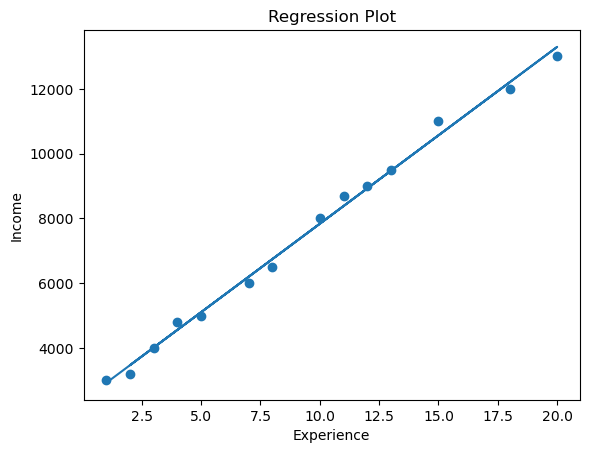


Insights:
- Experience has a significant positive effect.


C:\Users\YF\miniconda3\envs\datapie\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [17]:
analyze('test_data.csv','Experience','Income')

Summary有一些太详细了，可以精简一些重要的展示，分为普通用户版本和统计学家版本（做一个折叠？）